# Prediksi Harga Tiket Pesawat dengan LSTM

## Pendahuluan
Pada notebook ini, kita akan membuat model prediksi harga tiket pesawat menggunakan metode Long Short-Term Memory (LSTM). Model ini dirancang untuk menganalisis data historis harga tiket dan memberikan prediksi harga di masa depan. Tujuan dari model ini adalah untuk membantu pengguna memahami tren harga tiket pesawat.

## Import Library yang Dibutuhkan
Kita akan menggunakan beberapa library Python untuk melakukan analisis dan membangun model LSTM.


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error


## Langkah 1: Memuat Dataset
Dataset yang digunakan adalah data harga tiket pesawat dengan berbagai fitur seperti tanggal, harga, dan maskapai. Pastikan dataset sudah dalam format Excel (.xlsx).

In [2]:
# Memuat dataset
df = pd.read_excel("1_prediksi_harga_tiket_pesawat.xlsx", parse_dates=["Date"])

# Menampilkan data awal
df.head()

,Date,Airline,Route,Flight Price,Day of Week,Seasonality,Demand,Fuel Price,Event
0,2023-01-01,Batik Air,Medan-Jakarta,728771,Sunday,Holiday,Low,9294,New Year
1,2023-01-02,Sriwijaya Air,Surabaya-Makassar,858086,Monday,Peak Season,Medium,9262,Christmas
2,2023-01-03,Garuda,Jakarta-Singapore,1325057,Tuesday,Holiday,Medium,10386,New Year
3,2023-01-04,Garuda,Jakarta-Bali,1393736,Wednesday,Holiday,High,10341,Valentine's Day
4,2023-01-05,Batik Air,Jakarta-Bali,1199073,Thursday,Peak Season,High,9987,New Year


## Langkah 2: Preprocessing Data
Dataset akan diolah agar sesuai untuk model LSTM. Di sini kita akan mengatur kolom 'Date' sebagai index dan memilih hanya kolom 'Flight Price' untuk diprediksi.

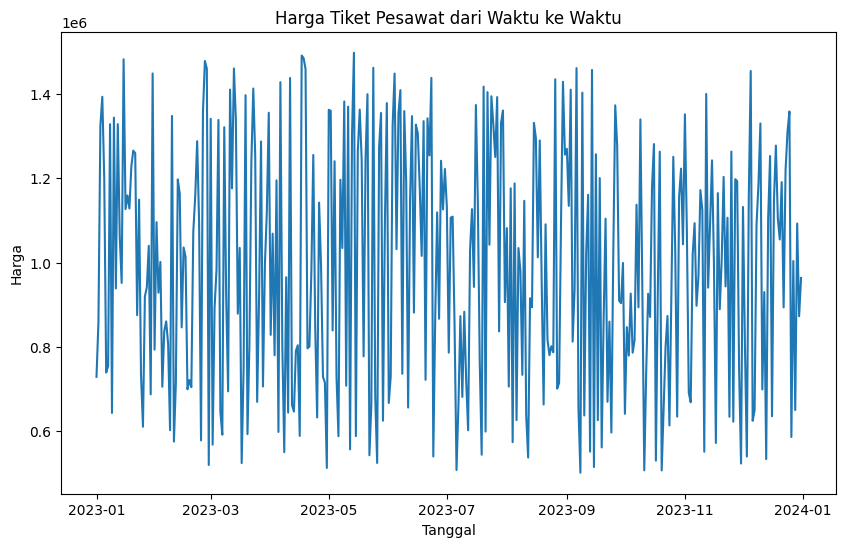

In [3]:
# Mengatur 'Date' sebagai index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Menggunakan hanya kolom 'Flight Price'
df = df[['Flight Price']]

# Visualisasi harga tiket pesawat
plt.figure(figsize=(10, 6))
plt.plot(df['Flight Price'])
plt.title('Harga Tiket Pesawat dari Waktu ke Waktu')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.show()

## Langkah 3: Normalisasi Data
Data harga tiket akan dinormalisasi menggunakan MinMaxScaler agar berada dalam rentang [0, 1]. Hal ini bertujuan untuk memperbaiki performa model LSTM.

In [4]:
# Normalisasi data harga tiket
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['Flight Price']])

## Langkah 4: Membagi Data Train dan Test
Data akan dibagi menjadi dua bagian: 80% untuk training dan 20% untuk testing.

In [5]:
# Membagi data menjadi train dan test
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

## Langkah 5: Membuat Dataset untuk LSTM
Kita akan membuat dataset berdasarkan time-step tertentu. Dalam hal ini, kita menggunakan 30 hari terakhir sebagai input untuk memprediksi harga tiket berikutnya.

In [6]:
# Fungsi untuk membuat dataset dengan time-step tertentu
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i+time_step, 0])
    return np.array(X), np.array(y)

# Membuat dataset train dan test
time_step = 30  # Menggunakan 30 hari terakhir
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

## Langkah 6: Membuat Model LSTM
Di langkah ini, kita akan membuat model LSTM dengan dua layer LSTM dan beberapa layer Dropout untuk mencegah overfitting.

In [7]:
# Membuat model LSTM
model = Sequential()

# Menambahkan LSTM layers
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Menambahkan layer output
model.add(Dense(units=1))

# Kompilasi model
model.compile(optimizer='adam', loss='mean_squared_error')

# Melatih model
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.2807 - val_loss: 0.0835
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1164 - val_loss: 0.0773
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0983 - val_loss: 0.0765
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0953 - val_loss: 0.0761
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0969 - val_loss: 0.0733
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0933 - val_loss: 0.0734
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0984 - val_loss: 0.0732
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0957 - val_loss: 0.0731
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0941 - val_loss: 0.0732
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0880 - val_loss: 0.0766
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0957 - val_loss: 0.0734
Epoch 12/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0925 - val_loss: 0.0728
Epoch 13/20


## Langkah 7: Prediksi Harga Tiket
Setelah model dilatih, kita akan menggunakannya untuk memprediksi harga tiket pesawat pada data testing.

In [8]:
# Prediksi harga tiket dengan model yang telah dilatih
predictions = model.predict(X_test)

# Mengembalikan skala data ke bentuk asli
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 399ms/step


## Langkah 8: Visualisasi Hasil Prediksi
Mari kita visualisasikan hasil prediksi harga tiket pesawat dibandingkan dengan harga aktual.

ValueError: x and y must have same first dimension, but have shapes (43,) and (42, 1)

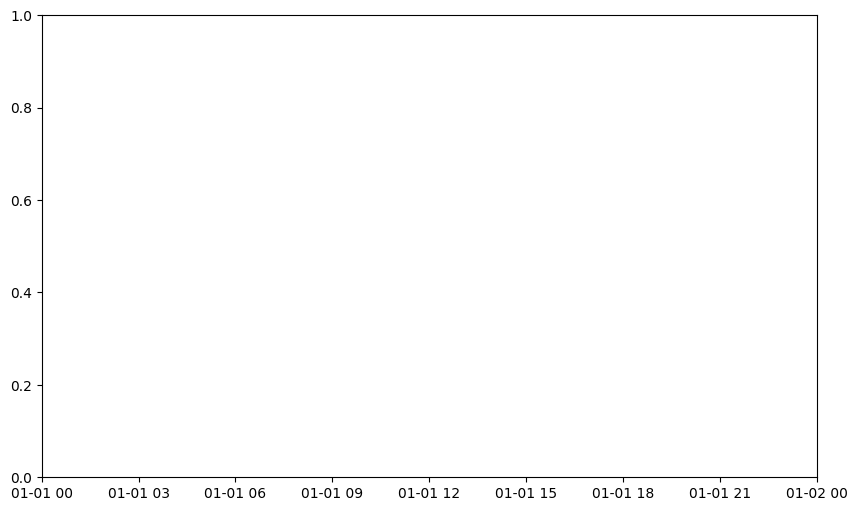

In [9]:
# Visualisasi hasil prediksi vs aktual
plt.figure(figsize=(10, 6))
plt.plot(df.index[len(train_data) + time_step:], y_test_actual, label='Harga Aktual')
plt.plot(df.index[len(train_data) + time_step:], predictions, label='Harga Prediksi')
plt.title('Prediksi Harga Tiket Pesawat')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend()
plt.show()

## Langkah 9: Evaluasi Model
Kita akan menggunakan Mean Squared Error (MSE) untuk mengevaluasi performa model dalam memprediksi harga tiket.

In [ ]:
# Menghitung Mean Squared Error (MSE)
mse = mean_squared_error(y_test_actual, predictions)
print(f'Mean Squared Error: {mse}')

## Kesimpulan
Model LSTM ini mampu memprediksi harga tiket pesawat berdasarkan tren historis. Dengan model ini, pengguna dapat mengetahui waktu terbaik untuk membeli tiket pesawat, berdasarkan tren yang dianalisis oleh model.